First we make sure we have acces to our database

In [16]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [17]:
df= kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "abrerjawod/student-mental-health-and-burnout-dataset",
    "Social_media_impact_on_life.csv"
)
df.head()

/tmp/ipykernel_5482/3490190219.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df= kagglehub.load_dataset(


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


Now we have access to the dataset, let´s try to uncover some insights to see how social media usage impacts in the students sleep and overall performance.

<Axes: xlabel='Age', ylabel='Avg_Daily_Usage_Hours'>

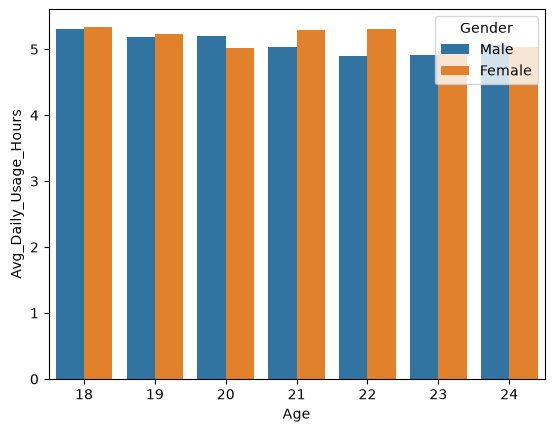

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=df,x="Age", y="Avg_Daily_Usage_Hours",errorbar=None,hue="Gender")

Seems like all the students from 18 to 24 have an average daily usage of five hours, that doesn´t decrease nor spikes with age,now let´s compare the different applications to see which one is the most addictive:

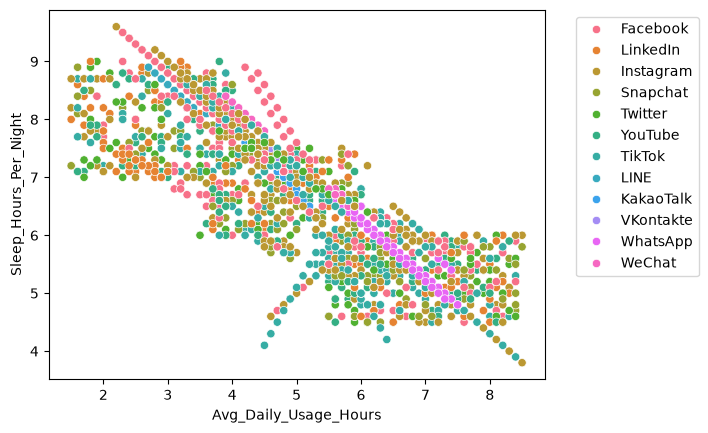

In [39]:
sns.scatterplot(data=df,x="Avg_Daily_Usage_Hours",y="Sleep_Hours_Per_Night",hue="Most_Used_Platform")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


We can extract an interesting fact and is that those who use their phone the most are the worst sleepers, let´s see how these affect their mental health by using the mental health score as the hue instead of the most used platform.

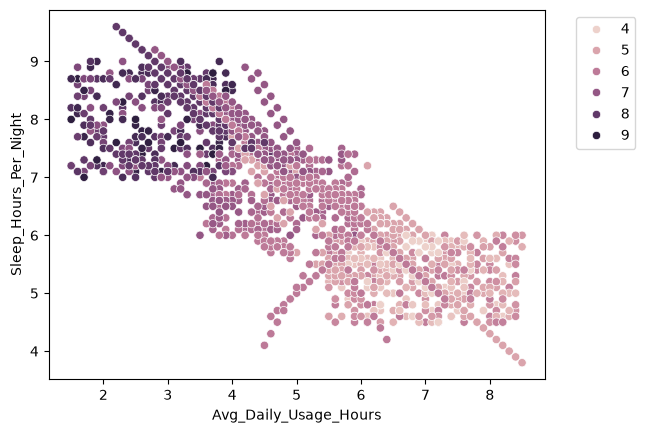

In [41]:
sns.scatterplot(data=df,x="Avg_Daily_Usage_Hours",y="Sleep_Hours_Per_Night",hue="Mental_Health_Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


We can clearly visualize that those who have more than 7 hours of sleep per night have substancially a better mental health than those who don´t.But going back to the platforms, let´s see wich is the most used platform overall.

In [56]:
df["Most_Used_Platform"].value_counts()

Most_Used_Platform
Instagram    389
TikTok       295
Facebook     256
LinkedIn     176
Twitter      170
YouTube      165
Snapchat     149
WhatsApp      54
WeChat        15
LINE          12
KakaoTalk     12
VKontakte     12
Name: count, dtype: int64

We can see that the most used platforms overall are Instagram, TikTok and Facebook, while others sit well behind, let´s do an analysis on the type of user of this three mos used platforms and see if we can have extract some insights

Text(0.5, 1.0, 'Academic Levels by Sleep hpurs and Daily Phone Usage')

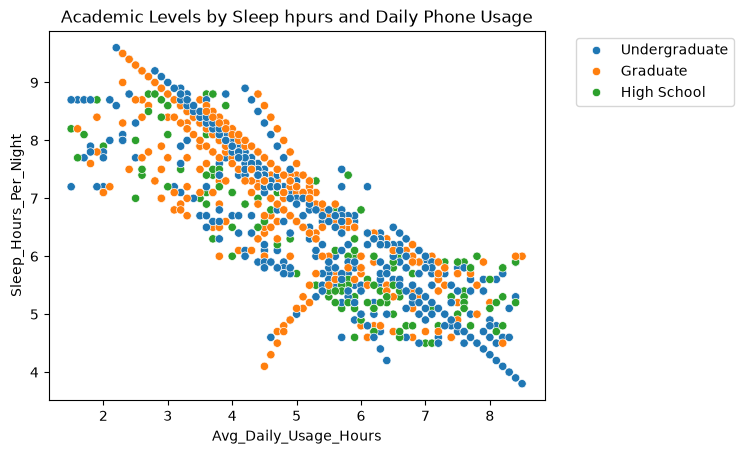

In [90]:
top_three = ["Facebook", "Instagram", "TikTok"]
filtered_df = df[df["Most_Used_Platform"].isin(top_three)]
sns.scatterplot(
    data=filtered_df,
    x="Avg_Daily_Usage_Hours",
    y="Sleep_Hours_Per_Night",
    hue="Academic_Level"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Academic Levels by Sleep hpurs and Daily Phone Usage")


As we can see a lot of those who use this platforms the most are in high school, they also have the worst sleep hours per night and the most averaage daily usage.Now let´s see the mental health score in different academic levels

Text(0.5, 1.0, 'Mental Health by Academic Levels by Gender')

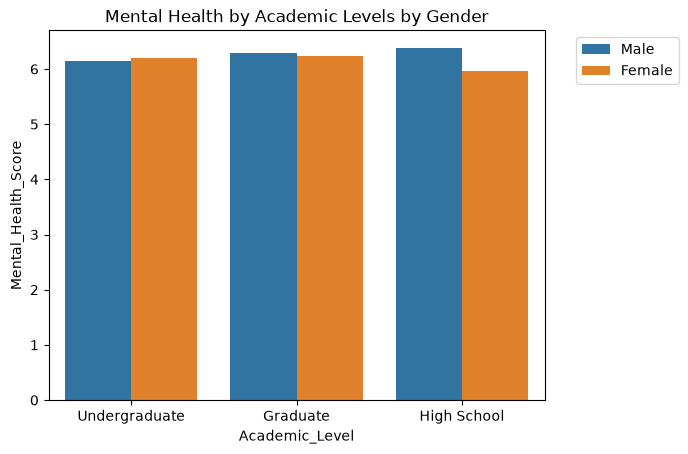

In [ ]:
sns.barplot(data=df,x="Academic_Level",y="Mental_Health_Score",errorbar=None,hue="Gender")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Mental Health by Academic Levels by Gender")

We can see that overall the mental health score is sitting in six regardless of their education level, except for females in high school wich seems to be slightly lower than everyone else, let´s see why

Text(0.5, 1.0, 'High School Boys and Girls Sleeping hours vs Avg Daily Phone Usage')

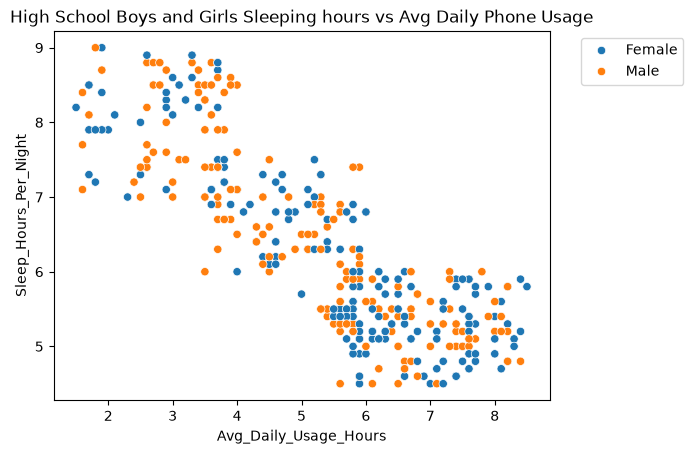

In [114]:
high_school=df["Academic_Level"]=="High School"
sns.scatterplot(data=df[high_school],x="Avg_Daily_Usage_Hours",y="Sleep_Hours_Per_Night",hue="Gender")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("High School Boys and Girls Sleeping hours vs Avg Daily Phone Usage")

We notice that the distribution between both is very much even,so it is not the usage hours what is causing this, but something ele, let´s try to find out by visualizing it otherwise by dive deeping into each specific group:

In [169]:
high_school_students=df[high_school]
girls=high_school_students["Gender"]=="Female"
boys=high_school_students["Gender"]=="Male"
high_school_girls=high_school_students[girls]
high_school_boys=high_school_students[boys]





In [ ]:
high_school_girls["Most_Used_Platform"].value_counts()

Most_Used_Platform
Instagram    34
YouTube      32
Facebook     25
TikTok       22
Snapchat     21
LinkedIn     20
Twitter      18
Name: count, dtype: int64

In [201]:
high_school_boys["Most_Used_Platform"].value_counts()

Most_Used_Platform
LinkedIn     33
TikTok       30
Snapchat     30
YouTube      26
Instagram    25
Facebook     21
Twitter      15
Name: count, dtype: int64

After taking a closer look at the most used apps for each group we see that boys are using more LinkedIn while girls are using more Instagram, this is already an insight but i think the actual thing would be to know the average daily usage per platform on each group. 

In [209]:
round(high_school_girls.groupby("Most_Used_Platform")["Avg_Daily_Usage_Hours"].sum()/high_school_students.groupby("Most_Used_Platform")["Avg_Daily_Usage_Hours"].sum()*100,2)

Most_Used_Platform
Facebook     54.71
Instagram    63.77
LinkedIn     37.65
Snapchat     44.51
TikTok       43.56
Twitter      47.62
YouTube      58.83
Name: Avg_Daily_Usage_Hours, dtype: float64

In [210]:
round(high_school_boys.groupby("Most_Used_Platform")["Avg_Daily_Usage_Hours"].sum()/high_school_students.groupby("Most_Used_Platform")["Avg_Daily_Usage_Hours"].sum()*100,2)

Most_Used_Platform
Facebook     45.29
Instagram    36.23
LinkedIn     62.35
Snapchat     55.49
TikTok       56.44
Twitter      52.38
YouTube      41.17
Name: Avg_Daily_Usage_Hours, dtype: float64

By taking a closer look we can see above that the girls usage of Instagram represented a 63,77% while boys did it on a 36.23%, also we can notice the heavy usage of boys in linkedIn representing 62,35% (slightly below girls Instagram usage) while girls usage of this platform represented only 37.65% .Let´s now analyze the sleep hours per night of this two groups and see what can we find